### Imports

In [21]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

________

In [2]:
def load_gaze(csv_path):
    df = pd.read_csv(csv_path)

    # Rename for consistency
    df = df.rename(columns={
        'Seconds': 'time',
        'GazeX': 'x',
        'GazeY': 'y'
    })

    # Convert time
    df['time'] = pd.to_datetime(df['time'])

    return df[['time', 'x', 'y']]

In [3]:
gaze_df = load_gaze("/home/s243636/master-thesis/supp/gaze/sub-OE002/ses-Hellerup/gaze.csv")
gaze_df.head()

,time,x,y
0,2024-06-27 06:49:20.044713708,684.03870,488.66174
1,2024-06-27 06:49:20.074729708,692.71780,422.27580
2,2024-06-27 06:49:20.080713708,629.63460,352.35130
3,2024-06-27 06:49:20.087721708,582.17580,372.18850
4,2024-06-27 06:49:20.122729708,374.60846,394.04465


In [4]:
gaze_df['dt'] = gaze_df['time'].diff().dt.total_seconds()
print(gaze_df['dt'].describe())

count    44661.000000
mean         0.033314
std          0.028478
min          0.000000
25%          0.020000
50%          0.031008
75%          0.036992
max          0.436000
Name: dt, dtype: float64


min being $0.000 s$ indicates that there are duplicated timestamps
and max being $0.436 s$ means that there is occasional gaps between observations

In [5]:
# Printing duplicated time rows
dup = gaze_df[gaze_df.duplicated(subset='time', keep=False)]
print(dup)

                               time          x         y        dt
1592  2024-06-27 06:50:13.085737708  463.89682  862.9679  0.011008
1593  2024-06-27 06:50:13.085737708  463.89682  862.9679  0.000000
1594  2024-06-27 06:50:13.085737708  463.89682  862.9679  0.000000
44655 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.016000
44656 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44657 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44658 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44659 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44660 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44661 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000


In [12]:
# Deleting duplicated rows based on above
gaze_df = gaze_df.drop_duplicates(subset='time')

# Check stats again to ensure min value changed
gaze_df['dt'] = gaze_df['time'].diff().dt.total_seconds()
print(gaze_df['dt'].describe())

count    44653.000000
mean         0.033320
std          0.028477
min          0.004992
25%          0.020000
50%          0.031008
75%          0.036992
max          0.436000
Name: dt, dtype: float64


In [9]:
gaze_df.head()

,time,x,y,dt
0,2024-06-27 06:49:20.044713708,684.03870,488.66174,NaN
1,2024-06-27 06:49:20.074729708,692.71780,422.27580,0.030016
2,2024-06-27 06:49:20.080713708,629.63460,352.35130,0.005984
3,2024-06-27 06:49:20.087721708,582.17580,372.18850,0.007008
4,2024-06-27 06:49:20.122729708,374.60846,394.04465,0.035008


Now with no duplicates and good quality data we actually begin the eye tracking part.

_______

In [18]:
def preprocess_gaze(df, x_col='x', y_col='y', time_col='time'):
    df = df.copy()

    # Sort by time
    df = df.sort_values(time_col)

    # Interpolate missing values
    df[x_col] = df[x_col].interpolate(limit=5)
    df[y_col] = df[y_col].interpolate(limit=5)

    # Remove remaining NaNs
    df = df.dropna(subset=[x_col, y_col])

    # Smoothing data with Savitzky-Golay
    if len(df) > 5:
        df['x_smooth'] = savgol_filter(df[x_col], 5, 2)
        df['y_smooth'] = savgol_filter(df[y_col], 5, 2)
    else:
        df['x_smooth'] = df[x_col]
        df['y_smooth'] = df[y_col]

    return df

In [19]:
gaze = preprocess_gaze(gaze_df)
gaze.head()

,time,x,y,dt,x_smooth,y_smooth
0,2024-06-27 06:49:20.044713708,684.03870,488.66174,NaN,678.962928,491.803820
1,2024-06-27 06:49:20.074729708,692.71780,422.27580,0.030016,695.351640,410.818983
2,2024-06-27 06:49:20.080713708,629.63460,352.35130,0.005984,652.187712,367.869272
3,2024-06-27 06:49:20.087721708,582.17580,372.18850,0.007008,538.997040,368.672943
4,2024-06-27 06:49:20.122729708,374.60846,394.04465,0.035008,413.674246,386.541165


Making sure no important data is left behind

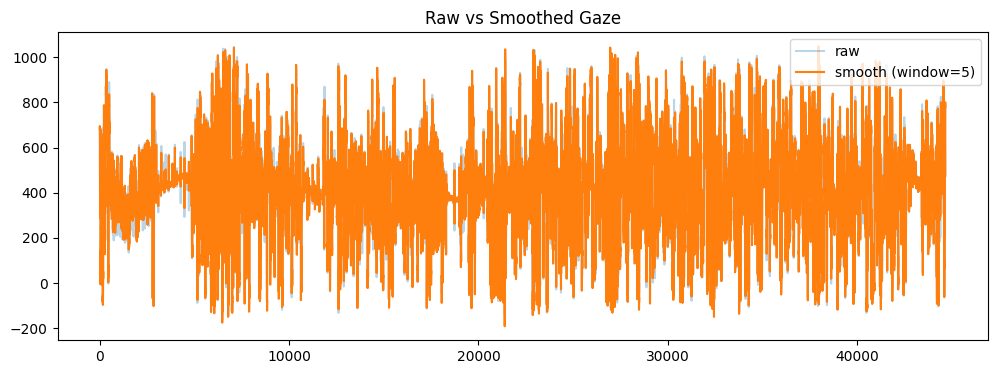

In [22]:
plt.figure(figsize=(12,4))
plt.plot(gaze['x'], alpha=0.3, label='raw')
plt.plot(gaze['x_smooth'], label='smooth (window=5)')
plt.legend()
plt.title("Raw vs Smoothed Gaze")
plt.show()